# Reactivo 1

In [53]:
#funcion para leer archivos

def get_texts_from_file(path_corpus, path_truth):

    tr_txt = []
    tr_y = []

    with open(path_corpus, "r", encoding="utf-8") as f_corpus, open(path_truth, "r", encoding="utf-8") as f_truth:
    
        for twitt in f_corpus:
            tr_txt += [twitt]

        for label in f_truth:
            tr_y += [label]


    return tr_txt, tr_y

In [54]:
tr_text, tr_y = get_texts_from_file("./mex20_train.txt", "./mex20_train_labels.txt")

In [55]:
def sortFreqDist(freqdict): 
    aux = [(freqdict[key], key)for key in freqdict]
    aux.sort()
    aux.reverse()
    return aux # se convierte en el diccionario

In [56]:
import nltk

corpus_palabras = []

from nltk.tokenize import TweetTokenizer
tokenizer = TweetTokenizer()

for doc in tr_text:
    corpus_palabras += tokenizer.tokenize(doc)

In [57]:
import nltk
from nltk.tokenize import TweetTokenizer

fdist = nltk.FreqDist(corpus_palabras)

V = sortFreqDist(fdist)[:6000]

tokenizer = TweetTokenizer()
tokenizer.tokenize(tr_text[154])

corpus_palabras = []

for doc in tr_text:
    corpus_palabras += tokenizer.tokenize(doc)

In [58]:
# Diccionario de Indices
dic_indices = dict() # dict_indices{PALABRA} = Indice en la bolsa de palabras, palabra mas frecuente 0

for i, word in enumerate(V):
    dic_indices[word[1]] = i

dic_indices

len(dic_indices)



6000

In [59]:
import numpy as np

def build_bow_tr(texts, V, dict_indices):
    import numpy as np
    BOW = np.zeros((len(texts), len(dict_indices)))
    cont_doc = 0
    
    for tr in texts:
        fdist_doc = nltk.FreqDist(tokenizer.tokenize(tr.lower()))
        for word in fdist_doc:
            if word in dict_indices:
                idx = dict_indices[word]
                BOW[cont_doc, idx] = fdist_doc[word]
        cont_doc += 1
    return BOW

def build_tfidf_tr(tr_txt, V, dict_indices): 

    N = len(tr_txt) # Número de documentos en el training
    TFIDF = np.zeros((N, len(V)), dtype=float)

    DF = np.zeros(len(V), dtype=float) # Vector que me dice para cada palabra en el vocabulario, cuantos documentos la contienen 

    # Calcular DF (Document Frequency)
    for doc in tr_txt: 
        palabras = tokenizer.tokenize(doc.lower()) # tokenizar
        palabras_unicas = set(palabras) 
        for w in palabras_unicas: 
            if w in dict_indices:
                DF[dict_indices[w]] += 1
                
    # Calcular IDF una sola vez después de tener todos los DF
    IDF = np.log((N+1)/(DF+1)) + 1 # Broad Casting
    
    # Calcular para cada tuit: TFIDF = TF * IDF
    for i, doc in enumerate(tr_txt): # Recorrer todos los documentos 
        fdist = nltk.FreqDist(tokenizer.tokenize(doc.lower())) # sacar palabras de cada tuit
        doc_len = len(fdist) # tamaño del documento
        for w, freq in fdist.items():
            if w in dict_indices: 
                TF = freq/doc_len # Frecuencia Normalizada 
                TFIDF[i,dict_indices[w]] = TF * IDF[dict_indices[w]] # combinación del pesado 
    return TFIDF


## Build the tf-idf

In [60]:
from sklearn import preprocessing


BOW_tr = build_tfidf_tr(tr_text, V, dic_indices)

BOW_tr = preprocessing.normalize(BOW_tr, norm='l2')

BOW_tr.shape

print(BOW_tr)

[[0.         0.1206922  0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.12281479 0.         ... 0.         0.         0.        ]
 ...
 [0.         0.09904877 0.         ... 0.         0.         0.        ]
 [0.15904699 0.         0.         ... 0.         0.         0.        ]
 [0.11140965 0.10463612 0.         ... 0.         0.         0.        ]]


In [61]:
val_text, val_y = get_texts_from_file("./mex20_val.txt", "./mex20_val_labels.txt")

## Build the svm lineal

In [62]:
BOW_val = build_tfidf_tr(val_text, V, dic_indices)
BOW_val = preprocessing.normalize(BOW_val, norm='l2')

In [63]:
tr_y = list(map(int, tr_y)) 
val_y = list(map(int, val_y)) 

from sklearn import svm
from sklearn.model_selection import GridSearchCV # Para varios experimentos y probar parametros
from sklearn import metrics
from sklearn.metrics import precision_recall_fscore_support

svm = svm.LinearSVC(class_weight='balanced') 

parameters = {'C': [.5, .12, .25, .5, 1, 2, 4]}
# varios experimentos a probar un parametro 
grid = GridSearchCV(estimator=svm, param_grid=parameters, n_jobs=4, scoring="f1_macro", cv=5 )

grid.fit(BOW_tr, tr_y) # llevar a cabo entrenamiento sobre la bolsa de palabras de TRAIN

y_pred = grid.predict(BOW_val)

In [64]:
print(metrics.classification_report(val_y, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.86      0.88       418
           1       0.69      0.75      0.72       169

    accuracy                           0.83       587
   macro avg       0.79      0.81      0.80       587
weighted avg       0.84      0.83      0.83       587



Se reporto un accuracy del 83%

## Chi squared

In [65]:
from sklearn.feature_selection import SelectKBest, chi2

feats_500 = SelectKBest(score_func=chi2, k=500)
feats_2000 = SelectKBest(score_func=chi2, k=2000)

feats_500.fit(BOW_tr, tr_y)
feats_2000.fit(BOW_tr, tr_y)

BOW_tr_k500 = feats_500.transform(BOW_tr)
BOW_val_k500 = feats_500.transform(BOW_val)

BOW_tr_k2000 = feats_2000.transform(BOW_tr)
BOW_val_k2000 = feats_2000.transform(BOW_val)



In [66]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score

parameters = {'C': [.5, .12, .25, .5, 1, 2, 4]}

# Modelo con chi2 k=500
grid_500 = GridSearchCV(estimator=svm, param_grid=parameters, n_jobs=4, scoring='f1_macro', cv=5)
grid_500.fit(BOW_tr_k500, tr_y)
y_pred_500 = grid_500.predict(BOW_val_k500)

# Modelo con chi2 k=2000
grid_2000 = GridSearchCV(estimator=svm, param_grid=parameters, n_jobs=4, scoring='f1_macro', cv=5)
grid_2000.fit(BOW_tr_k2000, tr_y)
y_pred_2000 = grid_2000.predict(BOW_val_k2000)

print("Chi squared 500")
print(classification_report(val_y, y_pred_500))

print("Chi squared 2000")
print(classification_report(val_y, y_pred_2000))

Chi squared 500
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       418
           1       0.67      0.75      0.71       169

    accuracy                           0.82       587
   macro avg       0.78      0.80      0.79       587
weighted avg       0.83      0.82      0.83       587

Chi squared 2000
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       418
           1       0.70      0.74      0.72       169

    accuracy                           0.83       587
   macro avg       0.80      0.81      0.80       587
weighted avg       0.84      0.83      0.83       587



## Tabla de resultados

| Configuracion | F1 macro |
|---|---:|
| Full (6000) | 0.83 |
| Chi squared (500) | 0.82 |
| Chi squared (2000) | 0.83 |

In [67]:
print("10 palabras mas relevantes segun chi squared con 2000 palabras")
best = feats_2000.get_support(indices=True)
dict_indice_invertido = {v: k for k, v in dic_indices.items()}
target_words = [dict_indice_invertido[i] for i in best]
target_words[:10]

10 palabras mas relevantes segun chi squared con 2000 palabras


10 palabras mas relevantes segun chi squared con 2000 palabras


[',', 'de', 'que', 'la', 'a', '!', 'me', 'el', 'en', 'verga']

Conclusion:

AL momento de usar en features con chi squared relativamente bajos, podemos ver que al momento de usar menos palabras, se pierde mucha informacion, por lo tanto no puede ver tan bien para donde dirigirse, pero a la vez al escoger las mejores palabras aunque sean poquitas como en el chi squared de 500, no se nota un gran bajon de calidad debido a que son las palabras mas relevantes

# Reactivo 2

## TCOR

In [68]:
def compute_tcor(BOW):

    DTR = np.zeros((BOW.shape[1], BOW.shape[1]), dtype=np.float64)

    for doc, i in zip(BOW, range(len(BOW))):
        nonzero_position = np.nonzero(doc)[0]
        for t1 in nonzero_position:
            for t2 in nonzero_position:
                DTR[t1, t2] += 1.0


    return DTR
        

In [69]:
from sklearn import preprocessing
TCOR_base = compute_tcor(BOW_tr) 
TCOR_base = preprocessing.normalize(TCOR_base, norm='l2')

len(TCOR_base)

6000

## Ponderación TCOR con TFIDF

In [70]:
# Ponderar TCOR con TFIDF
# Multiplicar cada vector de término por su valor TFIDF promedio

tfidf_promedio = BOW_tr.mean(axis=0)

TCOR_ponderado = TCOR_base.copy()

for i in range(TCOR_ponderado.shape[0]):
    TCOR_ponderado[i, :] = TCOR_ponderado[i, :] * tfidf_promedio[i]

print(f"TCOR ponderado shape: {TCOR_ponderado.shape}")

TCOR ponderado shape: (6000, 6000)


## Constelación con las 1000 palabras más importantes (Chi2)

In [71]:
# Seleccionar las 1000 mejores palabras según Chi2
feats_1000 = SelectKBest(score_func=chi2, k=1000)
feats_1000.fit(BOW_tr, tr_y)

# Obtener los índices de las 1000 palabras seleccionadas
indices_1000 = feats_1000.get_support(indices=True)

# Filtrar TCOR ponderado con solo las 1000 palabras
TCOR_1000 = TCOR_ponderado[indices_1000, :][:, indices_1000]

print(f"TCOR con 1000 palabras shape: {TCOR_1000.shape}")
print(f"Índices seleccionados: {len(indices_1000)}")

TCOR con 1000 palabras shape: (1000, 1000)
Índices seleccionados: 1000


/home/atzin/NLP/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129315 (\N{ROLLING ON THE FLOOR LAUGHING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/atzin/NLP/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127814 (\N{AUBERGINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/atzin/NLP/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/atzin/NLP/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128579 (\N{UPSIDE-DOWN FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/atzin/NLP/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128556 (\N{GRIMACING FACE}) missing from font(s) DejaVu Sans.
  fig.canv

/home/atzin/NLP/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129315 (\N{ROLLING ON THE FLOOR LAUGHING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/atzin/NLP/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127814 (\N{AUBERGINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/atzin/NLP/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/atzin/NLP/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128579 (\N{UPSIDE-DOWN FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/atzin/NLP/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128556 (\N{GRIMACING FACE}) missing from font(s) DejaVu Sans.
  fig.canv

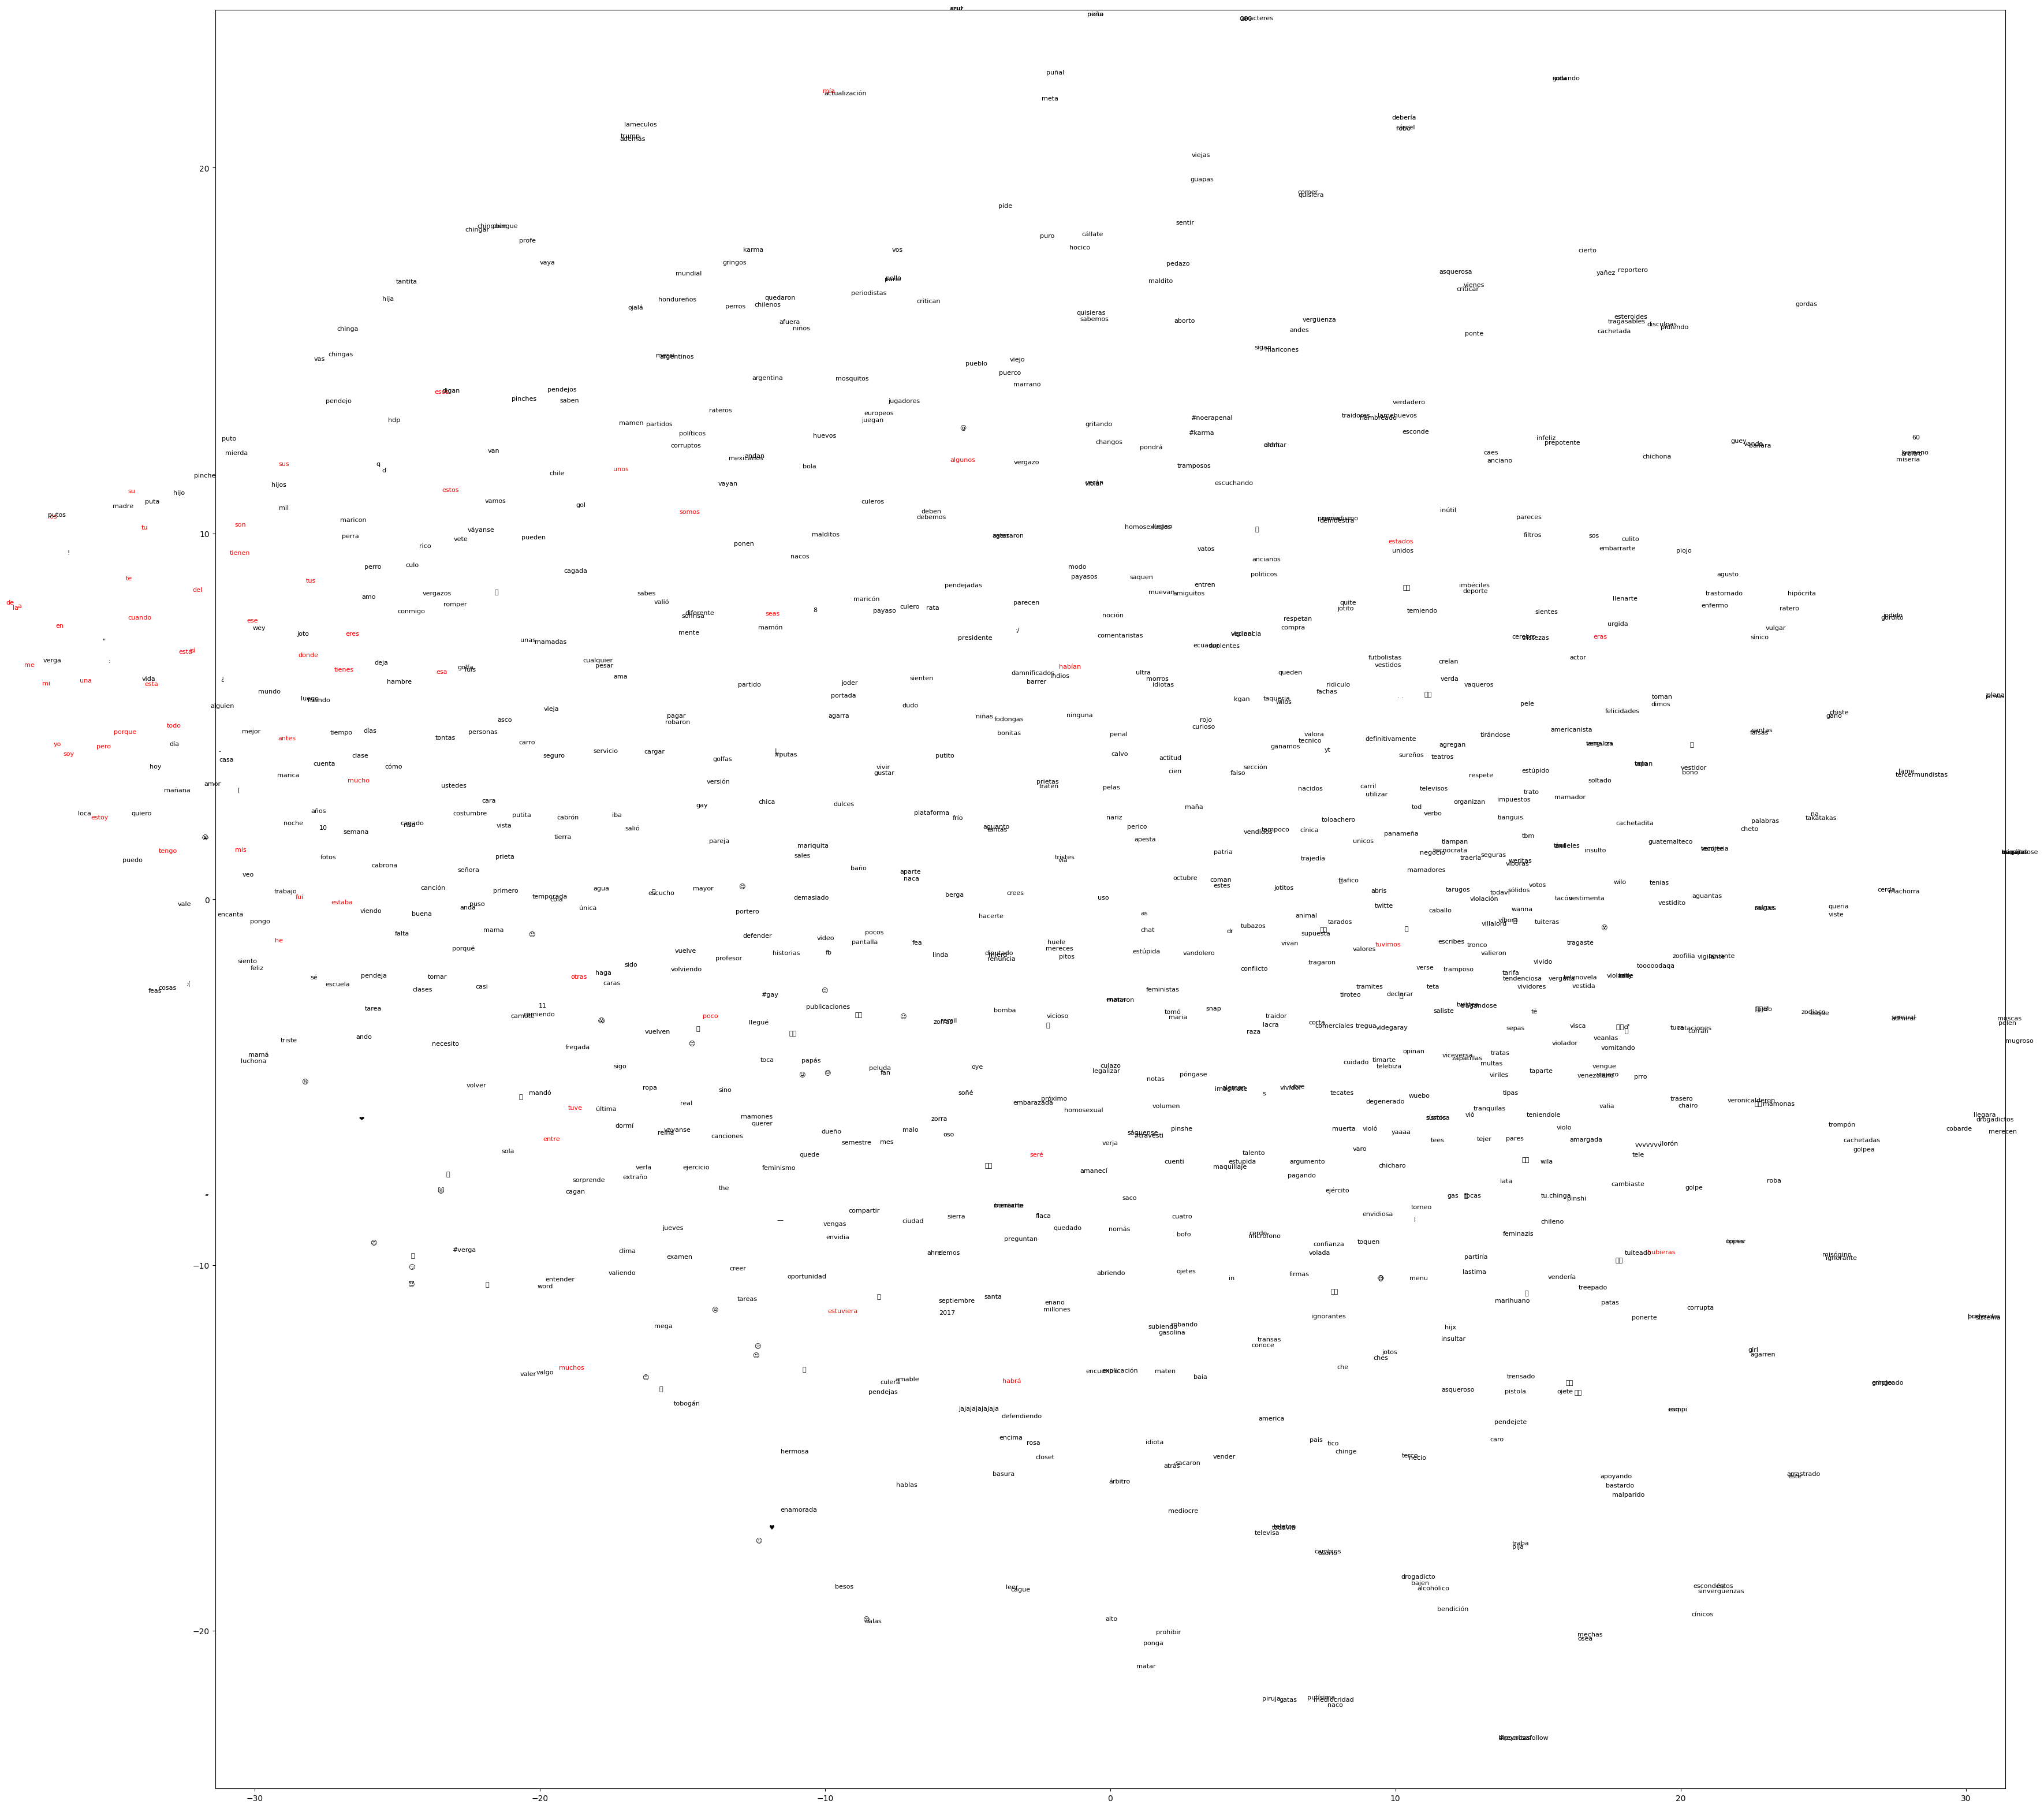

In [72]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import nltk

# Usar las 1000 palabras más relevantes según Chi2
# (se obtienen de indices_1000 en la celda anterior)
dict_indice_invertido = {v: k for k, v in dic_indices.items()}
target_words = [dict_indice_invertido[i] for i in indices_1000]

# Cada término se representa con su vector de co-ocurrencia en TCOR_1000
target_matrix = TCOR_1000

reduced_matrix = TSNE(n_components=2, random_state=42).fit_transform(target_matrix)
max_x = np.max(reduced_matrix, axis=0)[0]
max_y = np.max(reduced_matrix, axis=0)[1]

plt.figure(figsize=(40, 40), dpi=100)

plt.xlim(-max_x, max_x)
plt.ylim(-max_y, max_y)

# Pintar las palabras
from nltk.corpus import stopwords
try:
    stop_words = set(stopwords.words('spanish'))
except LookupError:
    nltk.download('stopwords', quiet=True)
    try:
        stop_words = set(stopwords.words('spanish'))
    except LookupError:
        stop_words = set()

for i, word in enumerate(target_words):
    x = reduced_matrix[i, 0]
    y = reduced_matrix[i, 1]
    if word in stop_words:
        plt.text(x, y, word, color='red', fontsize=8)  # Palabras vacías en rojo
    else:
        plt.text(x, y, word, fontsize=8)

plt.show()

In [73]:
#Escoger 10 palabras aleatorias de las 1000 seleccionadas
import random
random.seed(42)  
selected_indices = random.sample(list(indices_1000), 10)
selected_words = [dict_indice_invertido[i] for i in selected_indices]
print("Palabras seleccionadas para la gráfica de flechas:", selected_words)

Palabras seleccionadas para la gráfica de flechas: ['sepas', 'noche', 'porque', 'esconde', 'prietas', 'mayor', 'culero', 'asco', 'esteroides', 'culo']


In [74]:

t_words = target_words
subsetwords = selected_words
subreduced_matrix = []
ploted_subsetwords = []
for idx, word in enumerate(t_words[:]):
    if word in subsetwords:
        ploted_subsetwords += [word]
        subreduced_matrix += [reduced_matrix[idx]]

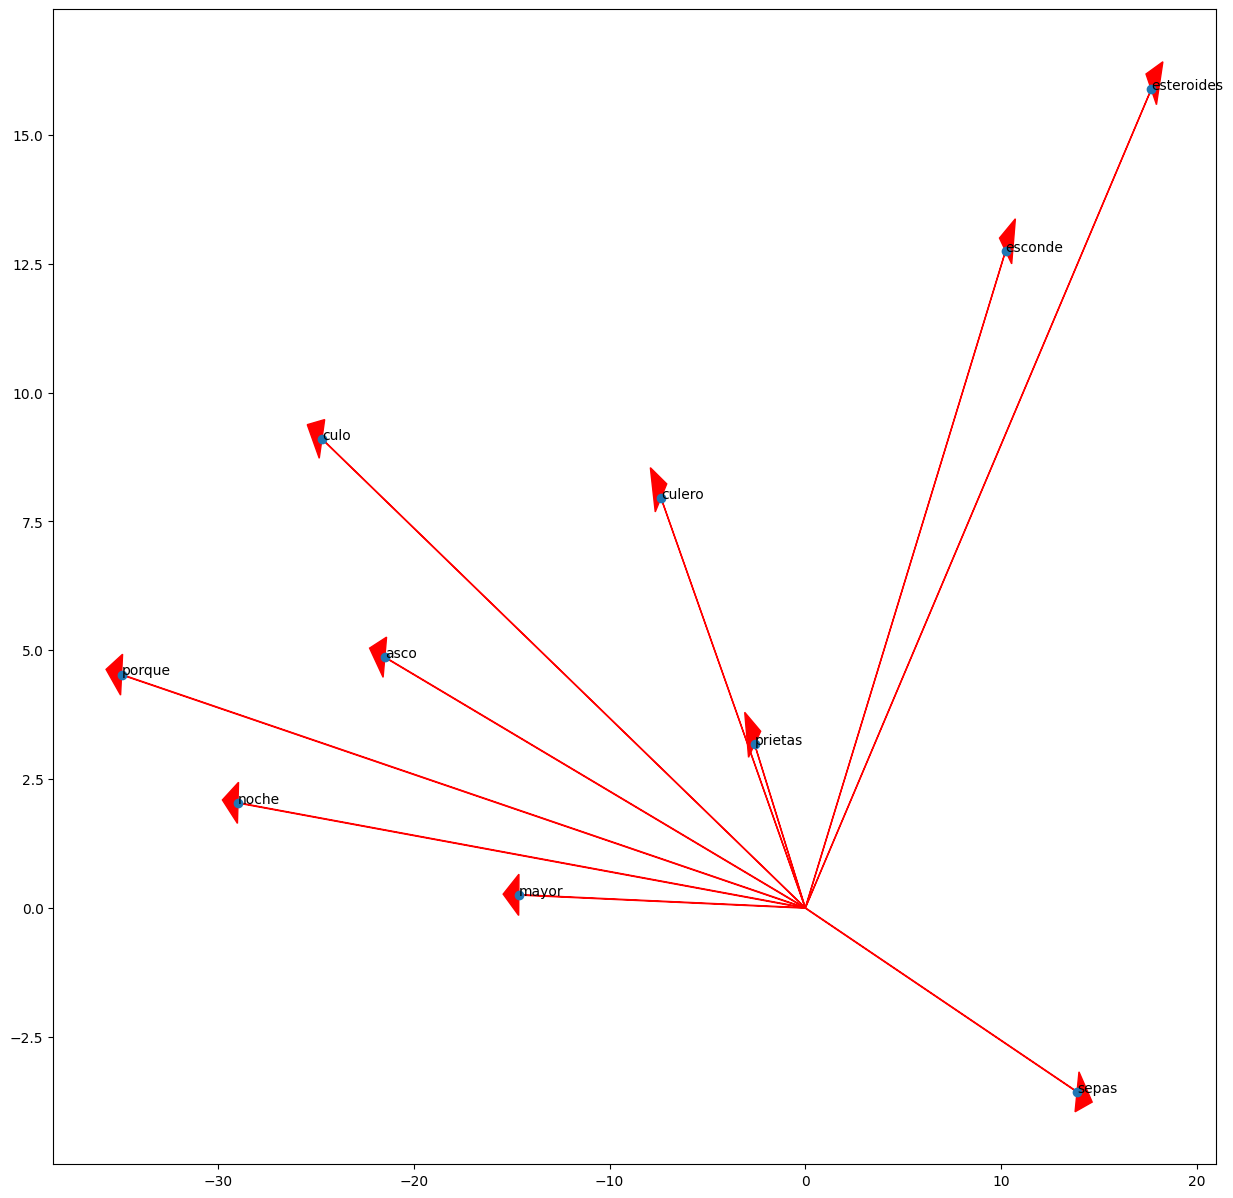

In [75]:
subreduced_matrix = np.array(subreduced_matrix)

fig, ax = plt.subplots(figsize = (15, 15))

col1 = 0
col2 = 1

for word in subreduced_matrix:
    ax.arrow(0, 0, word[col1], word[col2], head_width=0.8, head_length=0.8, fc='r', ec='r', width = 1e-2)
ax.scatter(subreduced_matrix[:,col1], subreduced_matrix[:,col2]) 

for i in range(0, len(ploted_subsetwords)):
    ax.annotate(ploted_subsetwords[i], (subreduced_matrix[i,col1], subreduced_matrix[i,col2]))
    
plt.show()

In [76]:
# Ponderación final de la matriz usando Chi2 del reactivo previo
# Multiplicar cada vector de término por su valor Chi2

chi2_scores = np.nan_to_num(feats_2000.scores_, nan=0.0, posinf=0.0, neginf=0.0)

TCOR_ponderado_final = TCOR_base.copy()

for i in range(TCOR_ponderado_final.shape[0]):
    TCOR_ponderado_final[i, :] = TCOR_ponderado_final[i, :] * chi2_scores[i]

print("TCOR_ponderado_final shape:", TCOR_ponderado_final.shape)

TCOR_ponderado_final shape: (6000, 6000)


Con la matriz ya dejamos de tratar todos los terminos por igual, ahora las palabras las discriminativas tienen mayor peso en la represetnación. Entonces la constelacion tiene a mostrar relaciones mas claras entre terminos relevantes y menos ruido de palabras poco informativas

# Reactivo 3

In [77]:
# 1) Usar una matriz TCOR del Reactivo 2 como representación de palabras
W_tcor = TCOR_ponderado_final

print("Matriz de representación de palabras:", W_tcor.shape)

Matriz de representación de palabras: (6000, 6000)


In [78]:
# 2) Representar cada tuit como promedio de vectores de palabras
X_tr = np.zeros((len(tr_text), W_tcor.shape[1]))
X_val = np.zeros((len(val_text), W_tcor.shape[1]))

for i, tw in enumerate(tr_text):
    words = tokenizer.tokenize(tw.lower())
    idxs = [dic_indices[w] for w in words if w in dic_indices]
    if len(idxs) > 0:
        X_tr[i, :] = np.mean(W_tcor[idxs, :], axis=0)

for i, tw in enumerate(val_text):
    words = tokenizer.tokenize(tw.lower())
    idxs = [dic_indices[w] for w in words if w in dic_indices]
    if len(idxs) > 0:
        X_val[i, :] = np.mean(W_tcor[idxs, :], axis=0)

print("Train:", X_tr.shape)
print("Valid:", X_val.shape)

Train: (5278, 6000)
Valid: (587, 6000)


In [79]:
# 3) Entrenar el mismo clasificador SVM
parameters = {'C': [.5, .12, .25, .5, 1, 2, 4]}

grid = GridSearchCV(estimator=svm, param_grid=parameters, n_jobs=4, scoring="f1_macro", cv=5)
grid.fit(X_tr, tr_y)

y_pred_tcor = grid.predict(X_val)

/home/atzin/NLP/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/atzin/NLP/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/atzin/NLP/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/atzin/NLP/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/atzin/NLP/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/atzin/NLP/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Li

In [80]:
# 4) Evaluar con Accuracy
acc_tcor = metrics.accuracy_score(val_y, y_pred_tcor)
print("Accuracy (promedio de vectores TCOR):", acc_tcor)

Accuracy (promedio de vectores TCOR): 0.848381601362862


## Tabla de resultados

| Configuracion | F1 macro |
|---|---:|
| Full (6000) | 0.83 |
| Chi squared (500) | 0.82 |
| Chi squared (2000) | 0.83 |
| TCOR (promedio de vectores) | 0.84 |

Accuracy del TCOR es del 0.84

la configuracion que fuciono mejor fue la basada en TCOR con el accuracy de 0.84, ya que tenemos relaciones de entre palabras que aporta infromacion semantica, mientras las palabras que no aportan mucho se pierden